In [1]:
%load_ext autoreload
%autoreload 2

# 7. LightGBM Analysis


In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_features
from src.models.splitting import split_train_holdout
from src.utils.metrics import rmse, mae, wrmsse_m5, absolute_error
from src.utils.helpers import load_pickle


## Config

In [3]:
# Configure experiment
artifact_dir = Path('../experiments/exp_001_lgbm/artifacts')

artifact_dir.mkdir(parents=True, exist_ok=True)

store_filter = ['CA_1', 'TX_1']

split_test_date = pd.Timestamp('2016-04-24') #-28 days from the last date in the dataset
split_validation_date = pd.Timestamp('2016-03-27') #-28 days from the test date
target_col = 'sales'
drop_cols = ['id', 'date', target_col]

feature_path = Path('../data/features')
df = load_features(feature_path, store_filter=store_filter)
print(f'Loaded features from: {feature_path}')

# Holdout data for testing and training/validation 
train_df, test_df = split_train_holdout(df, split_date=split_test_date)

Applied store filter: ['CA_1', 'TX_1']
Loaded features from: ..\data\features


## Load Results

In [4]:
if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'
    
# Load X_train and X_test_predict 
x_train_path = artifact_dir / f'X_train_{store_suffix}.parquet'
X_train = pd.read_parquet(x_train_path)

X_test_predict_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'
X_test_predict = pd.read_parquet(X_test_predict_path)

print(f'✓ X_train and X_test_predict loaded from {x_train_path} and {X_test_predict_path}')

# Load model
model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'
model = load_pickle(model_path)

# Load predictions
results_path = artifact_dir / f'predictions_{store_suffix}.parquet'
predictions_df = pd.read_parquet(results_path)

print(f'✓ Predictions loaded from {results_path}')

# Load sample predictions
sample_path = artifact_dir / f'sample_{store_suffix}.parquet'
selected_predictions= pd.read_parquet(sample_path)

✓ X_train and X_test_predict loaded from ..\experiments\exp_001_lgbm\artifacts\X_train_CA_1_TX_1.parquet and ..\experiments\exp_001_lgbm\artifacts\X_test_predict_CA_1_TX_1.parquet
Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl
✓ Predictions loaded from ..\experiments\exp_001_lgbm\artifacts\predictions_CA_1_TX_1.parquet


# Analysis

### Results structure

In [5]:
results_structure_df = pd.DataFrame({
    'metric': [
        'rows',
        'series',
        'forecast_days',
        'start_date',
        'end_date',
        'y_true_mean',
        'y_pred_mean',
    ],
    'value': [
        len(predictions_df),
        predictions_df['id'].nunique(),
        predictions_df['date'].nunique(),
        predictions_df['date'].min(),
        predictions_df['date'].max(),
        predictions_df['y_true'].mean(),
        predictions_df['y_pred'].mean(),
    ]
})

results_structure_df

,metric,value
0,rows,170744
1,series,6098
2,forecast_days,28
3,start_date,2016-04-25 00:00:00
4,end_date,2016-05-22 00:00:00
5,y_true_mean,1.3562
6,y_pred_mean,1.342035


### Forecast metrics

In [6]:
metrics_df = pd.DataFrame({
    'metric': ['RMSE', 'MAE'],
    'value': [
        rmse(
            predictions_df['y_true'],
            predictions_df['y_pred']
        ),
        mae(
            predictions_df['y_true'],
            predictions_df['y_pred']
        ),
    ]
})

metrics_df

,metric,value
0,RMSE,1.962880
1,MAE,1.020805


In [7]:
wrmsse_test_df = (
    test_df[
        [
            'id',
            'item_id',
            'dept_id',
            'cat_id',
            'store_id',
            'state_id',
            'date',
            'sales',
            'sell_price',
        ]
    ]
    .merge(
        predictions_df[
            ['id', 'date', 'y_pred']
        ],
        on=['id', 'date'],
        how='left',
        validate='one_to_one'
    )
)

wrmsse_value, wrmsse_levels_df = wrmsse_m5(
    df_train=train_df,
    df_test=wrmsse_test_df,
    target_col='sales',
    pred_col='y_pred',
    price_col='sell_price',
)

print(f'WRMSSE: {wrmsse_value:.4f}')

wrmsse_levels_df

WRMSSE: 0.5455


,level,n_series,wrmsse
0,total,1,0.353773
1,state,2,0.405137
2,store,2,0.405137
3,category,3,0.414781
4,department,7,0.487420
5,state_category,6,0.491230
6,state_department,14,0.557723
7,store_category,6,0.491230
8,store_department,14,0.557723
9,item,3049,0.790731


### y_true × y_pred

In [8]:
# Actual vs predicted

actual_predicted_df = predictions_df[
    ['id', 'date', 'y_true', 'y_pred']
].copy()

actual_predicted_df

,id,date,y_true,y_pred
0,FOODS_1_001_CA_1,2016-04-25,2,0.980432
1,FOODS_1_001_TX_1,2016-04-25,0,0.071717
2,FOODS_1_002_CA_1,2016-04-25,0,0.404134
3,FOODS_1_002_TX_1,2016-04-25,6,0.051275
4,FOODS_1_003_CA_1,2016-04-25,3,0.713605
...,...,...,...,...
170739,HOUSEHOLD_2_514_TX_1,2016-05-22,0,0.383686
170740,HOUSEHOLD_2_515_CA_1,2016-05-22,0,0.451014
170741,HOUSEHOLD_2_515_TX_1,2016-05-22,0,0.413844
170742,HOUSEHOLD_2_516_CA_1,2016-05-22,0,0.393045


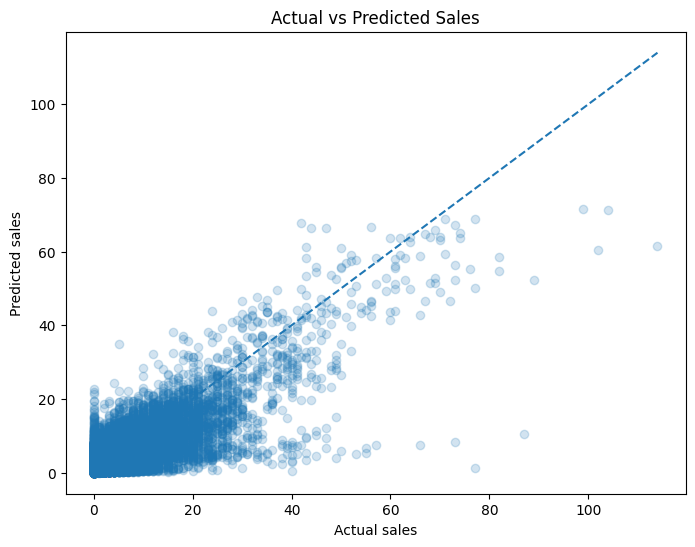

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_predicted_df['y_true'],
    actual_predicted_df['y_pred'],
    alpha=0.2
)

max_value = max(
    actual_predicted_df['y_true'].max(),
    actual_predicted_df['y_pred'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

plt.xlabel('Actual sales')
plt.ylabel('Predicted sales')
plt.title('Actual vs Predicted Sales')

plt.show()

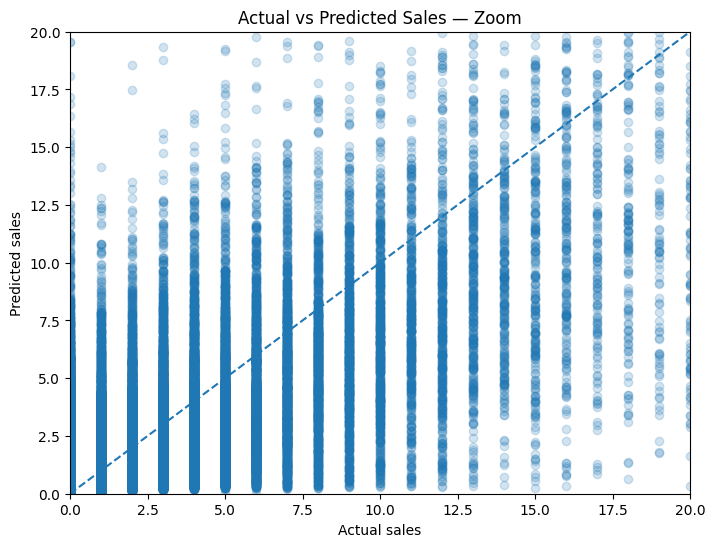

In [10]:
actual_predicted_zoom_df = actual_predicted_df[
    (actual_predicted_df['y_true'] <= 20) &
    (actual_predicted_df['y_pred'] <= 20)
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_predicted_zoom_df['y_true'],
    actual_predicted_zoom_df['y_pred'],
    alpha=0.2
)

plt.plot(
    [0, 20],
    [0, 20],
    linestyle='--'
)

plt.xlim(0, 20)
plt.ylim(0, 20)

plt.xlabel('Actual sales')
plt.ylabel('Predicted sales')
plt.title('Actual vs Predicted Sales — Zoom')

plt.show()

### Resíduos

In [11]:
# Residual analysis

residuals_df = predictions_df[
    ['id', 'date', 'y_true', 'y_pred']
].copy()

residuals_df['residual'] = (
    residuals_df['y_true']
    - residuals_df['y_pred']
)

residuals_df['absolute_error'] = absolute_error(
    residuals_df['y_true'],
    residuals_df['y_pred']
)

residuals_df

,id,date,y_true,y_pred,residual,absolute_error
0,FOODS_1_001_CA_1,2016-04-25,2,0.980432,1.019568,1.019568
1,FOODS_1_001_TX_1,2016-04-25,0,0.071717,-0.071717,0.071717
2,FOODS_1_002_CA_1,2016-04-25,0,0.404134,-0.404134,0.404134
3,FOODS_1_002_TX_1,2016-04-25,6,0.051275,5.948725,5.948725
4,FOODS_1_003_CA_1,2016-04-25,3,0.713605,2.286395,2.286395
...,...,...,...,...,...,...
170739,HOUSEHOLD_2_514_TX_1,2016-05-22,0,0.383686,-0.383686,0.383686
170740,HOUSEHOLD_2_515_CA_1,2016-05-22,0,0.451014,-0.451014,0.451014
170741,HOUSEHOLD_2_515_TX_1,2016-05-22,0,0.413844,-0.413844,0.413844
170742,HOUSEHOLD_2_516_CA_1,2016-05-22,0,0.393045,-0.393045,0.393045


In [12]:
residuals_summary_df = residuals_df[
    ['residual', 'absolute_error']
].describe()

residuals_summary_df

,residual,absolute_error
count,170744.000000,170744.000000
mean,0.014165,1.020805
std,1.962835,1.676565
min,-30.023939,0.000005
25%,-0.563608,0.304433
50%,-0.281153,0.534236
75%,0.473966,1.081583
max,76.629591,76.629591


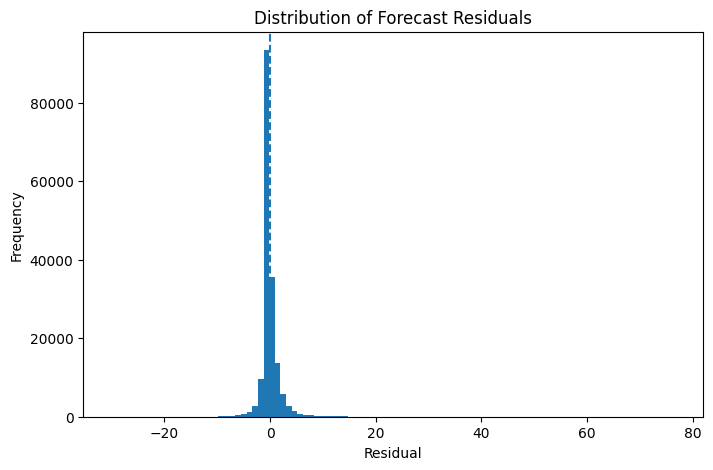

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals_df['residual'],
    bins=100
)

plt.axvline(0, linestyle='--')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Forecast Residuals')

plt.show()

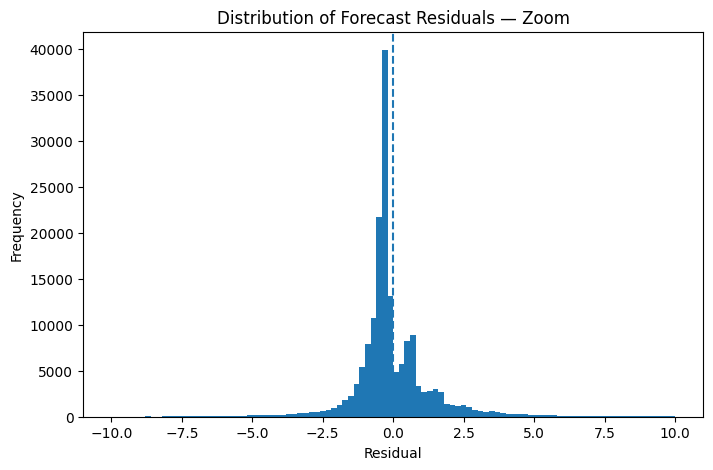

In [14]:
residuals_zoom_df = residuals_df[
    residuals_df['residual'].between(-10, 10)
].copy()

plt.figure(figsize=(8, 5))

plt.hist(
    residuals_zoom_df['residual'],
    bins=100
)

plt.axvline(0, linestyle='--')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Forecast Residuals — Zoom')

plt.show()

### Zeros

In [15]:
# Zero-demand analysis

zeros_df = predictions_df[
    ['id', 'date', 'y_true', 'y_pred']
].copy()

zeros_df['is_zero'] = zeros_df['y_true'] == 0

zeros_df['absolute_error'] = absolute_error(
    zeros_df['y_true'],
    zeros_df['y_pred']
)

zeros_df

,id,date,y_true,y_pred,is_zero,absolute_error
0,FOODS_1_001_CA_1,2016-04-25,2,0.980432,False,1.019568
1,FOODS_1_001_TX_1,2016-04-25,0,0.071717,True,0.071717
2,FOODS_1_002_CA_1,2016-04-25,0,0.404134,True,0.404134
3,FOODS_1_002_TX_1,2016-04-25,6,0.051275,False,5.948725
4,FOODS_1_003_CA_1,2016-04-25,3,0.713605,False,2.286395
...,...,...,...,...,...,...
170739,HOUSEHOLD_2_514_TX_1,2016-05-22,0,0.383686,True,0.383686
170740,HOUSEHOLD_2_515_CA_1,2016-05-22,0,0.451014,True,0.451014
170741,HOUSEHOLD_2_515_TX_1,2016-05-22,0,0.413844,True,0.413844
170742,HOUSEHOLD_2_516_CA_1,2016-05-22,0,0.393045,True,0.393045


In [16]:
zeros_summary_df = (
    zeros_df
    .groupby('is_zero')
    .agg(
        observations=('y_true', 'size'),
        mean_y_true=('y_true', 'mean'),
        mean_y_pred=('y_pred', 'mean'),
        mean_absolute_error=('absolute_error', 'mean')
    )
    .reset_index()
)

zeros_summary_df

,is_zero,observations,mean_y_true,mean_y_pred,mean_absolute_error
0,False,75007,3.087219,2.245222,1.513979
1,True,95737,0.000000,0.634415,0.634418


In [17]:
zero_rate_df = pd.DataFrame({
    'metric': [
        'zero_observations',
        'non_zero_observations',
        'zero_rate'
    ],
    'value': [
        zeros_df['is_zero'].sum(),
        (~zeros_df['is_zero']).sum(),
        zeros_df['is_zero'].mean()
    ]
})

zero_rate_df

,metric,value
0,zero_observations,95737.000000
1,non_zero_observations,75007.000000
2,zero_rate,0.560705


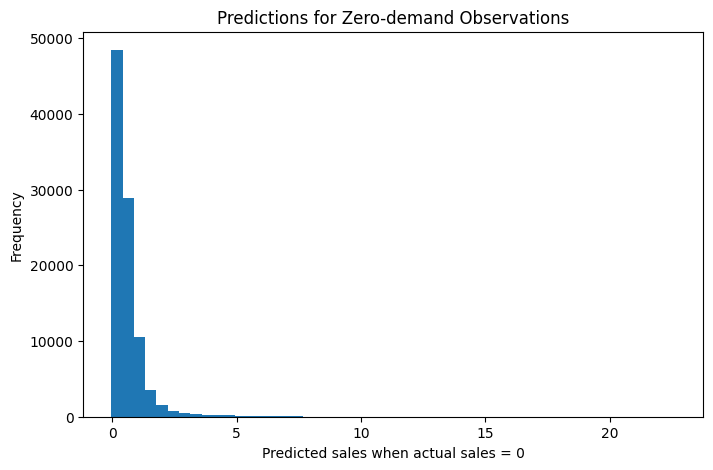

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    zeros_df.loc[zeros_df['is_zero'], 'y_pred'],
    bins=50
)

plt.xlabel('Predicted sales when actual sales = 0')
plt.ylabel('Frequency')
plt.title('Predictions for Zero-demand Observations')

plt.show()

### Cone de resíduos

In [19]:
# Residual cone

residual_cone_df = predictions_df[
    ['id', 'date', 'y_true', 'y_pred']
].copy()

residual_cone_df['residual'] = (
    residual_cone_df['y_true']
    - residual_cone_df['y_pred']
)

residual_cone_df['absolute_error'] = np.abs(
    residual_cone_df['residual']
)

residual_cone_df

,id,date,y_true,y_pred,residual,absolute_error
0,FOODS_1_001_CA_1,2016-04-25,2,0.980432,1.019568,1.019568
1,FOODS_1_001_TX_1,2016-04-25,0,0.071717,-0.071717,0.071717
2,FOODS_1_002_CA_1,2016-04-25,0,0.404134,-0.404134,0.404134
3,FOODS_1_002_TX_1,2016-04-25,6,0.051275,5.948725,5.948725
4,FOODS_1_003_CA_1,2016-04-25,3,0.713605,2.286395,2.286395
...,...,...,...,...,...,...
170739,HOUSEHOLD_2_514_TX_1,2016-05-22,0,0.383686,-0.383686,0.383686
170740,HOUSEHOLD_2_515_CA_1,2016-05-22,0,0.451014,-0.451014,0.451014
170741,HOUSEHOLD_2_515_TX_1,2016-05-22,0,0.413844,-0.413844,0.413844
170742,HOUSEHOLD_2_516_CA_1,2016-05-22,0,0.393045,-0.393045,0.393045


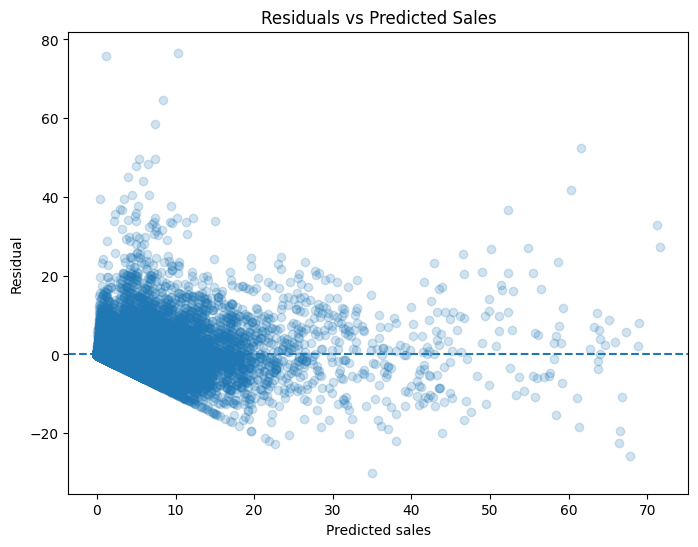

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    residual_cone_df['y_pred'],
    residual_cone_df['residual'],
    alpha=0.2
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Predicted sales')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Sales')

plt.show()

### Forecast error by horizon

In [21]:


horizon_error_df = predictions_df.copy()

first_forecast_date = horizon_error_df['date'].min()

horizon_error_df['horizon'] = (
    horizon_error_df['date'] - first_forecast_date
).dt.days + 1

horizon_error_df['absolute_error'] = absolute_error(
    horizon_error_df['y_true'],
    horizon_error_df['y_pred']
)

horizon_error_df['squared_error'] = (
    horizon_error_df['y_true']
    - horizon_error_df['y_pred']
) ** 2

horizon_error_df['residual'] = (
    horizon_error_df['y_true']
    - horizon_error_df['y_pred']
)

In [22]:
horizon_metrics_df = (
    horizon_error_df
    .groupby('horizon')
    .agg(
        observations=('y_true', 'size'),
        y_true_mean=('y_true', 'mean'),
        y_pred_mean=('y_pred', 'mean'),
        bias=('residual', 'mean'),
        mae=('absolute_error', 'mean'),
        mse=('squared_error', 'mean')
    )
    .reset_index()
)

horizon_metrics_df['rmse'] = np.sqrt(
    horizon_metrics_df['mse']
)

horizon_metrics_df

,horizon,observations,y_true_mean,y_pred_mean,bias,mae,mse,rmse
0,1,6098,1.237783,1.196701,0.041082,0.863650,2.565841,1.601824
1,2,6098,1.075107,1.119216,-0.044109,0.843298,2.244052,1.498016
2,3,6098,1.098557,1.116276,-0.017719,0.866454,3.097383,1.759938
3,4,6098,1.030174,1.118764,-0.088590,0.851719,2.454860,1.566799
4,5,6098,1.354542,1.230976,0.123567,0.967111,3.086644,1.756885
5,6,6098,1.631683,1.579431,0.052252,1.088768,4.247245,2.060885
6,7,6098,1.772548,1.721162,0.051386,1.183227,4.880087,2.209092
7,8,6098,1.255002,1.322048,-0.067047,0.970306,2.773795,1.665472
8,9,6098,1.280912,1.278286,0.002626,0.998835,3.689965,1.920928
9,10,6098,1.159888,1.197449,-0.037560,0.942268,3.213593,1.792650


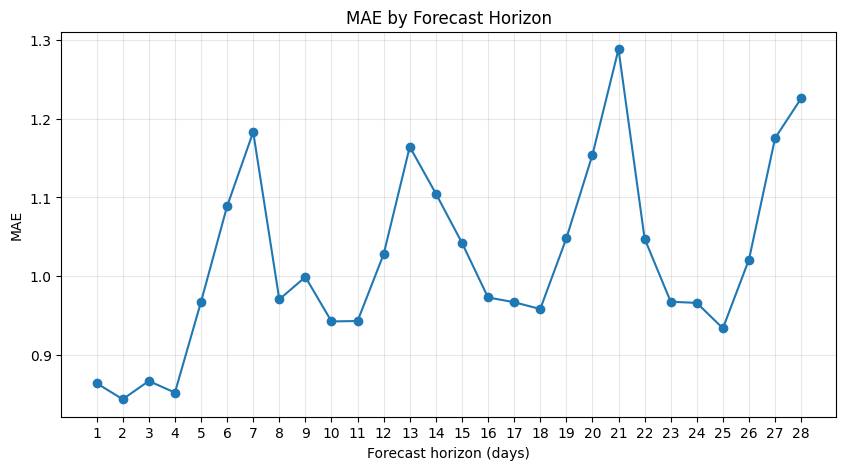

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_metrics_df['horizon'],
    horizon_metrics_df['mae'],
    marker='o'
)

plt.xlabel('Forecast horizon (days)')
plt.ylabel('MAE')
plt.title('MAE by Forecast Horizon')

plt.xticks(range(1, 29))
plt.grid(alpha=0.3)

plt.show()

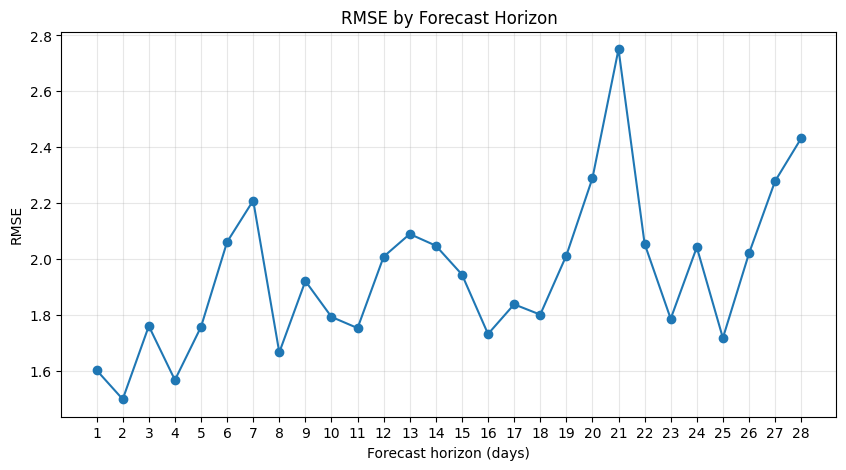

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_metrics_df['horizon'],
    horizon_metrics_df['rmse'],
    marker='o'
)

plt.xlabel('Forecast horizon (days)')
plt.ylabel('RMSE')
plt.title('RMSE by Forecast Horizon')

plt.xticks(range(1, 29))
plt.grid(alpha=0.3)

plt.show()